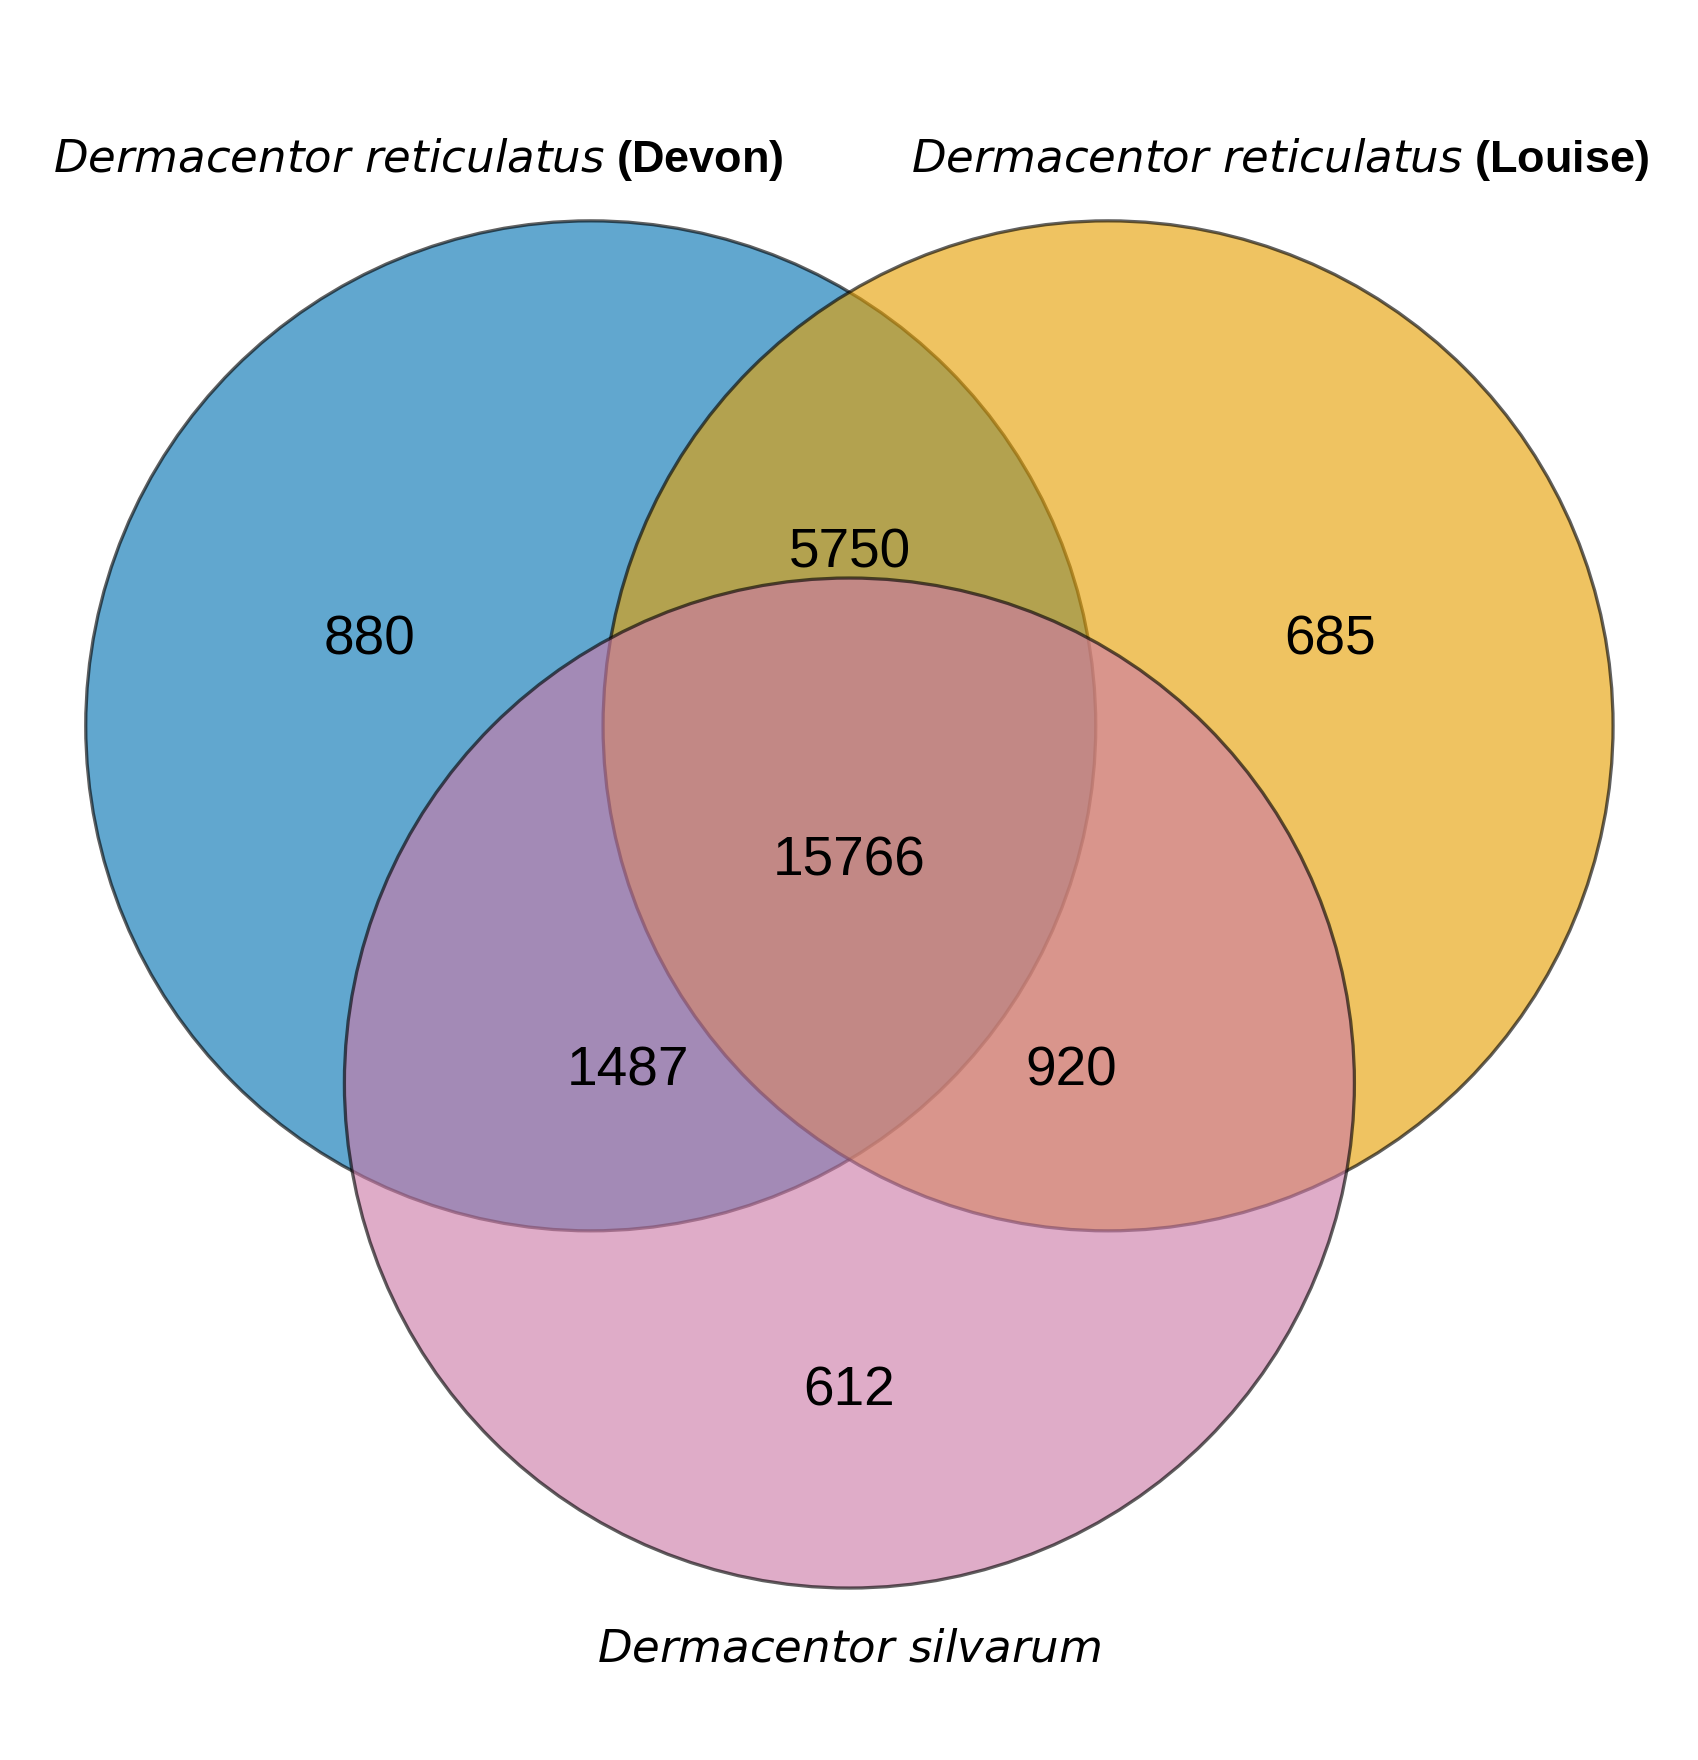

,Category,Orthogroups
0,Dermacentor reticulatus (Devon) only,880
1,Dermacentor reticulatus (Louise) only,685
2,Dermacentor silvarum only,612
3,Devon + Louise,5750
4,Devon + Dermacentor silvarum,1487
5,Louise + Dermacentor silvarum,920
6,All three,15766


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Circle
from matplotlib import font_manager as fm

df = pd.read_csv("/content/Orthogroups.tsv", sep="\t")

a = "Devon_Dretic_Racon"
b = "Louise_Dretic_Elska"
c = "Silvarum"

A = df[a].fillna("").astype(str).str.strip().ne("")
B = df[b].fillna("").astype(str).str.strip().ne("")
C = df[c].fillna("").astype(str).str.strip().ne("")

a_only = (A & ~B & ~C).sum()
b_only = (~A & B & ~C).sum()
c_only = (~A & ~B & C).sum()
ab = (A & B & ~C).sum()
ac = (A & ~B & C).sum()
bc = (~A & B & C).sum()
abc = (A & B & C).sum()

font = (
    "Arial"
    if "Arial" in {f.name for f in fm.fontManager.ttflist}
    else "Liberation Sans"
)

mpl.rcParams.update({
    "font.family": font,
    "font.size": 14,
    "figure.dpi": 180,
    "savefig.dpi": 300
})

fig, ax = plt.subplots(figsize=(12, 10))

for x, y, color in [
    (-0.42, 0.20, "#0072B2"),
    (0.42, 0.20, "#E69F00"),
    (0.00, -0.38, "#CC79A7")
]:
    ax.add_patch(
        Circle(
            (x, y),
            0.82,
            facecolor=color,
            edgecolor="black",
            linewidth=1.3,
            alpha=0.62
        )
    )

count_style = {
    "fontsize": 22,
    "fontfamily": font,
    "ha": "center",
    "va": "center",
    "color": "black"
}

ax.text(-0.78, 0.34, str(a_only), **count_style)
ax.text(0.78, 0.34, str(b_only), **count_style)
ax.text(0.00, -0.88, str(c_only), **count_style)

ax.text(0.00, 0.48, str(ab), **count_style)
ax.text(-0.36, -0.36, str(ac), **count_style)
ax.text(0.36, -0.36, str(bc), **count_style)

ax.text(0.00, -0.02, str(abc), **count_style)

label_style = {
    "fontsize": 18,
    "fontfamily": font,
    "fontweight": "bold",
    "ha": "center",
    "va": "center",
    "color": "black"
}

ax.text(
    -0.70, 1.12,
    r"$\it{Dermacentor\ reticulatus}$ (Devon)",
    **label_style
)

ax.text(
    0.70, 1.12,
    r"$\it{Dermacentor\ reticulatus}$ (Louise)",
    **label_style
)

ax.text(
    0.00, -1.30,
    r"$\it{Dermacentor\ silvarum}$",
    **label_style
)

ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.45, 1.35)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.savefig("Dermacentor_venn.png", dpi=300, bbox_inches="tight")
plt.savefig("Dermacentor_venn.tiff", dpi=300, bbox_inches="tight")
plt.show()

summary = pd.DataFrame({
    "Category": [
        "Dermacentor reticulatus (Devon) only",
        "Dermacentor reticulatus (Louise) only",
        "Dermacentor silvarum only",
        "Devon + Louise",
        "Devon + Dermacentor silvarum",
        "Louise + Dermacentor silvarum",
        "All three"
    ],
    "Orthogroups": [
        a_only,
        b_only,
        c_only,
        ab,
        ac,
        bc,
        abc
    ]
})

display(summary)
summary.to_csv("Dermacentor_venn_summary.csv", index=False)